In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay


In [3]:
from google.colab import files
uploaded = files.upload()

Saving diabetes.csv to diabetes.csv
Saving heart.csv to heart.csv
Saving iris (1).csv to iris (1).csv


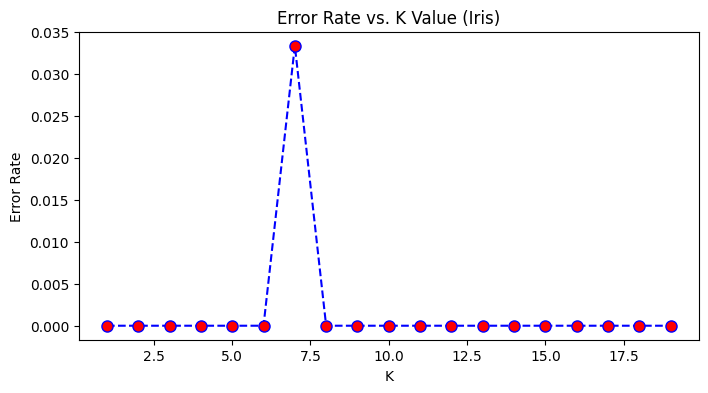

Accuracy Score for Iris (K=3): 1.0000

Confusion Matrix (Iris):
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report (Iris):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [4]:
iris_df = pd.read_csv('iris (1).csv')
X_iris = iris_df.iloc[:, :-1].values
y_iris = iris_df.iloc[:, -1].values

X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(X_iris, y_iris, test_size=0.2, random_state=42)

error_rates = []
for i in range(1, 20):
    knn_temp = KNeighborsClassifier(n_neighbors=i)
    knn_temp.fit(X_train_i, y_train_i)
    pred_i = knn_temp.predict(X_test_i)
    error_rates.append(np.mean(pred_i != y_test_i))

plt.figure(figsize=(8, 4))
plt.plot(range(1, 20), error_rates, color='blue', linestyle='dashed', marker='o', markerfacecolor='red', markersize=8)
plt.title('Error Rate vs. K Value (Iris)')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.show()

k_iris = 3
knn_iris = KNeighborsClassifier(n_neighbors=k_iris)
knn_iris.fit(X_train_i, y_train_i)
y_pred_iris = knn_iris.predict(X_test_i)

print(f"Accuracy Score for Iris (K={k_iris}): {accuracy_score(y_test_i, y_pred_iris):.4f}")
print("\nConfusion Matrix (Iris):")
print(confusion_matrix(y_test_i, y_pred_iris))
print("\nClassification Report (Iris):")
print(classification_report(y_test_i, y_pred_iris))

In [5]:
diabetes_df = pd.read_csv('diabetes.csv')
X_diab = diabetes_df.iloc[:, :-1].values
y_diab = diabetes_df.iloc[:, -1].values

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(X_diab, y_diab, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_d = scaler.fit_transform(X_train_d)
X_test_d = scaler.transform(X_test_d)

k_diab = 5
knn_diab = KNeighborsClassifier(n_neighbors=k_diab)
knn_diab.fit(X_train_d, y_train_d)
y_pred_diab = knn_diab.predict(X_test_d)

print(f"Accuracy Score for Diabetes (K={k_diab}): {accuracy_score(y_test_d, y_pred_diab):.4f}")
print("\nConfusion Matrix (Diabetes):")
print(confusion_matrix(y_test_d, y_pred_diab))

Accuracy Score for Diabetes (K=5): 0.6948

Confusion Matrix (Diabetes):
[[79 20]
 [27 28]]


Best K value found: 7 with an accuracy of 0.9180


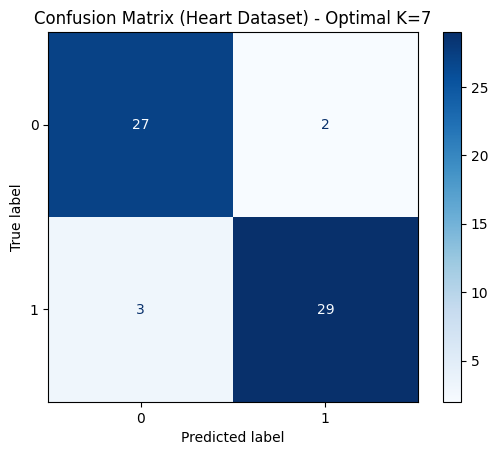


Classification Report (Heart Dataset):
              precision    recall  f1-score   support

           0       0.90      0.93      0.92        29
           1       0.94      0.91      0.92        32

    accuracy                           0.92        61
   macro avg       0.92      0.92      0.92        61
weighted avg       0.92      0.92      0.92        61



In [6]:
heart_df = pd.read_csv('heart.csv')
X_heart = heart_df.iloc[:, :-1].values
y_heart = heart_df.iloc[:, -1].values

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(X_heart, y_heart, test_size=0.2, random_state=42)

scaler_h = StandardScaler()
X_train_h = scaler_h.fit_transform(X_train_h)
X_test_h = scaler_h.transform(X_test_h)

best_k = 1
max_score = 0
for k in range(1, 21):
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train_h, y_train_h)
    score = knn_temp.score(X_test_h, y_test_h)
    if score > max_score:
        max_score = score
        best_k = k

print(f"Best K value found: {best_k} with an accuracy of {max_score:.4f}")

knn_heart = KNeighborsClassifier(n_neighbors=best_k)
knn_heart.fit(X_train_h, y_train_h)
y_pred_heart = knn_heart.predict(X_test_h)

cm_heart = confusion_matrix(y_test_h, y_pred_heart)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_heart)
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix (Heart Dataset) - Optimal K={best_k}')
plt.show()

print("\nClassification Report (Heart Dataset):")
print(classification_report(y_test_h, y_pred_heart))
